# Glitchgram Analysis

Description [...]

## Libraries

In [222]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from astropy.time import Time
from datetime import datetime, timedelta

## Functions

In [223]:
def create_glitchgram(unclustered, clustered, deltat, 
                         fmin=3, fmax=8192, tbins=41, fbins=30):
    
    all_glitchgrams = []
    rel_times = []
    
    """
    This function create one glitchgram from unclustered Omicron data, for each glitch.

    Parameters:
        df_triggers (dataFrame): A dataFrame of GPStimes of all triggers inside of some window.
        tmin, tmax (numbers): limits of GPStimes that contain all triggers of some glitch.
        fmin, fmax (numbers): frequency range for the glitchgram.
        n_time_bins (int): number of time bins.
        n_freq_bins (int): number of frequency bins.
        norm (boolean): True if you need normalize SNR values.

    Returns:
        array for some glitch: each entry is a SNR value from flattened (binsf × binst) matrix.
    """

    times_all = unclustered['time'].values
    freqs_all = unclustered['frequency'].values
    snrs_all  = unclustered['snr'].values

    time_edges = np.linspace(-deltat/2, deltat/2, tbins+1)
    freq_edges = np.logspace(np.log10(fmin), np.log10(fmax), fbins+1)
    
    for i, row in enumerate(clustered.itertuples(index=False)):

        #t_center = getattr(row, 'GPStime')
        t_center = row.time
    
        tmin = t_center - deltat/2
        tmax = t_center + deltat/2
    
        i0 = np.searchsorted(times_all, tmin, side="left")
        i1 = np.searchsorted(times_all, tmax, side="right")
    
        times = times_all[i0:i1] - t_center
        freqs = freqs_all[i0:i1]
        snrs  = snrs_all[i0:i1]

        '''if len(times) < 10: # Equivalente ao tcut
            continue'''
    
        df_triggers = pd.DataFrame({'time': times,'frequency': freqs,'snr': snrs})
        
        t_idx = np.digitize(df_triggers['time'].values, time_edges) - 1
        f_idx = np.digitize(df_triggers['frequency'].values, freq_edges) - 1
            
        # initial empty matrix
        A = np.zeros((fbins, tbins), dtype=float)
    
        for ti, fi, si in zip(t_idx, f_idx, snrs):
            if 0 <= ti < tbins and 0 <= fi < fbins:
                if si > A[fi, ti]:
                    A[fi, ti] = si
                    
        '''# normalização do SNR 
        if len(snrs) > 0:
            snr_min = snrs.min()
            snr_max = snrs.max()
            if snr_max > snr_min:
                norm_snrs = (snrs - snr_min) / (snr_max - snr_min)
            else:
                norm_snrs = np.zeros_like(snrs)
        else:
            norm_snrs = snrs'''

        all_glitchgrams.append(A)
        rel_times.append(t_center)
    
    return all_glitchgrams, rel_times

In [266]:
def plot_comparison(indices_sorteados, array, times, title, run):
    fig, axes = plt.subplots(2, 5, figsize=(10,4))
    axes = axes.flatten()
    
    fig.suptitle(f"{run} Matrices {title}", fontsize=12, fontweight='bold')

    
    
    for i, idx in enumerate(indices_sorteados):

        t_short = str(int(times[i]))[-7:]
        
        matriz = array[idx]
        ax = axes[i]
        
        im = ax.imshow(matriz)
        ax.set_title(f"#{idx} - {t_short}")
    
    plt.tight_layout()
    plt.show()

In [267]:
def plot_grid(arr, times, title):
    n = len(arr)
    if n == 0:
        print(f"Nenhum glitch encontrado em {title}")
        return
    
    cols = 5
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2))
    axes = np.atleast_1d(axes).flatten()
    
    fig.suptitle(f"{title} (Total: {n})", fontsize=12, fontweight='bold')
    
    for i in range(n):
        axes[i].imshow(arr[i], origin='lower', aspect='auto')

        t_short = str(int(times[i]))[-7:]
        axes[i].set_title(f"#{i} - {t_short}", fontsize=9)
        axes[i].axis('off')
        
    for j in range(n, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

## Parameters

In [283]:
# general parameters
clust_dim = 1
# deltat = 2.0
temp_dist = 0.1
# freq_dist = 0.2

filterr = False

# variables under consideration
min_triggers = 40
max_time_gap = 0.2
max_freq_gap = 0.20


# strings
clust, run = 'teste', 'O3a'
# triggers_name = 'triggers_total_' + run
sufixo = '_filtered_' if filterr else '_'

In [284]:
base = os.getcwd()
repository = base + '/zrepository'
temp = repository + '/' + clust + '/' + run + '/' + str(clust_dim) + 'D_dailyClustering_c' + str(min_triggers)

daily_clustering = (temp + '_f' + str(freq_dist) if clust_dim == 2 else temp) + '_gapt' + str(max_time_gap) + '_gapf' + str(max_freq_gap)

In [285]:
base

'/home/esanches/Projetos/tSNE/Virgo'

In [286]:
repository

'/home/esanches/Projetos/tSNE/Virgo/zrepository'

In [288]:
daily_clustering

'/home/esanches/Projetos/tSNE/Virgo/zrepository/teste/O3a/1D_dailyClustering_c40_gapt0.2_gapf0.2'

## Generate MATCHEDs and Non-MATCHEDs Data

In [289]:
if clust_dim == 1:
    arq_name = 'clustered' + sufixo + 'c' + str(min_triggers) + '_gapt' + str(max_time_gap) + '_gapf' + str(max_freq_gap) + '.csv'
else:
    arq_name = 'clustered' + sufixo + 'c' + str(min_triggers) + '_gapt' + str(max_time_gap) + '_gapf' + str(max_freq_gap) + '.csv'

df = repository + '/' + clust + '/' + run + '/' + arq_name
df

'/home/esanches/Projetos/tSNE/Virgo/zrepository/teste/O3a/clustered_c40_gapt0.2_gapf0.2.csv'

In [290]:
gdchar_data = pd.read_csv(df)
gdchar_data.tail(3)

,cluster,num_triggers,tstart,tend,time,frequency,min_freq,max_freq,snr
4385,91682.0,98.0,1.247700e+09,1.247700e+09,1.247700e+09,20.913994,17.578755,26.742411,8.983240
4386,91733.0,9312.0,1.247701e+09,1.247701e+09,1.247701e+09,32.842241,16.116238,1684.277014,595.648812
4387,91940.0,64.0,1.247702e+09,1.247702e+09,1.247702e+09,19.494597,17.731117,808.628577,6.986120


In [291]:
gps_start

np.float64(1246752018.0)

In [292]:
gps_end

np.float64(1247698818.0)

In [293]:
gspy_data = pd.read_csv(base + '/gspy' + run + '.csv')
# gspy_data = gspy_data[gspy_data['confidence'] >= 0.9]

start_day_O3a = datetime(2019, 7, 10, 0, 0, 0)
end_day_O3a   = datetime(2019, 7, 20, 23, 0, 0)

gps_start = Time(start_day_O3a, scale="utc").gps
gps_end   = Time(end_day_O3a, scale="utc").gps

gspy_data = gspy_data[(gspy_data['GPStime'] >= gps_start) & (gspy_data['GPStime'] <= gps_end)].sort_values(by='GPStime').reset_index(drop=True)
gspy_data

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
0,1.246810e+09,33.461,135.052,5.080000e-21,2634.428,3.500,5236.856445,0.0,0.0,0.997,f7rqwaplz2,V1,Extremely_Loud,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657
1,1.246810e+09,27.550,23.952,1.480000e-21,570.151,2.250,1108.301147,0.0,0.0,0.994,nwxWNjUZL9,V1,Extremely_Loud,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
2,1.246810e+09,126.704,12.729,1.410000e-22,385.997,0.750,739.993652,0.0,0.0,0.474,M00Foq5txZ,V1,Koi_Fish,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,11.314
3,1.246810e+09,180.679,8.087,1.530000e-22,223.913,0.014,307.875031,0.0,0.0,1.000,4NgEiYNMOT,V1,Blip,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657
4,1.246810e+09,77.754,8.936,1.680000e-22,198.803,0.039,358.096100,0.0,0.0,0.996,U0dpLRj7A2,V1,Blip,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,5.657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2709,1.247697e+09,381.052,9.098,1.720000e-22,275.179,0.422,226.310623,0.0,0.0,0.483,rrN1oWcKCx,V1,No_Glitch,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
2710,1.247697e+09,162.791,9.709,1.440000e-22,1630.742,1.172,2958.897217,0.0,0.0,0.653,rJeiA3OUDd,V1,No_Glitch,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
2711,1.247697e+09,162.791,9.382,1.480000e-22,165.221,0.344,20.805531,0.0,0.0,0.823,R9QoQ56qIs,V1,No_Glitch,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
2712,1.247697e+09,162.791,7.526,1.180000e-22,162.246,0.219,11.675120,0.0,0.0,0.934,yvnOW9SvwK,V1,No_Glitch,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255


In [294]:
gdchar_sorted = gdchar_data.sort_values("time").reset_index(drop=True)
gspy_sorted = gspy_data.sort_values("GPStime").reset_index(drop=True)

matched_df = pd.merge_asof(gspy_sorted, gdchar_sorted, left_on="GPStime", right_on="time", direction="nearest", tolerance=0.2)

matched_raw = matched_df.dropna(subset=["time"]).copy()
matched_raw["dt"] = (matched_raw["GPStime"] - matched_raw["time"]).abs()

matched = matched_raw.sort_values("dt").drop_duplicates(subset=["time"]).drop(columns=["dt"]).sort_index().reset_index(drop=True)

# non_matched_gspy = gspy_sorted[~gspy_sorted["GPStime"].isin(matched["GPStime"])].reset_index(drop=True)
non_matched_gspy = gspy_sorted[~gspy_sorted.index.isin(matched.index)].reset_index(drop=True)
non_matched_gdchar = gdchar_sorted[~gdchar_sorted["time"].isin(matched["time"])].reset_index(drop=True)

In [295]:
matched.tail(2)

,GPStime,peakFreq,snr_x,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,...,Q-value,cluster,num_triggers,tstart,tend,time,frequency,min_freq,max_freq,snr_y
1887,1.247697e+09,162.791,9.382,1.480000e-22,165.221,0.344,20.805531,0.0,0.0,0.823,...,45.255,91350.0,54.0,1.247697e+09,1.247697e+09,1.247697e+09,163.398668,157.355623,314.765637,9.246032
1888,1.247698e+09,19.950,8.063,1.860000e-21,20.195,1.125,8.390090,0.0,0.0,0.929,...,22.627,91485.0,44.0,1.247698e+09,1.247698e+09,1.247698e+09,19.494597,16.889483,21.775510,7.815850


In [296]:
non_matched_gspy.tail(2)

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
823,1.247697e+09,162.791,7.526,1.180000e-22,162.246,0.219,11.67512,0.0,0.0,0.934,yvnOW9SvwK,V1,No_Glitch,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,45.255
824,1.247698e+09,19.950,8.063,1.860000e-21,20.195,1.125,8.39009,0.0,0.0,0.929,oGhdmUbs86,V1,Low_Frequency_Lines,https://ldas-jobs.ligo.caltech.edu/~gravityspy...,22.627


In [297]:
non_matched_gdchar.tail(2)

,cluster,num_triggers,tstart,tend,time,frequency,min_freq,max_freq,snr
2497,91733.0,9312.0,1.247701e+09,1.247701e+09,1.247701e+09,32.842241,16.116238,1684.277014,595.648812
2498,91940.0,64.0,1.247702e+09,1.247702e+09,1.247702e+09,19.494597,17.731117,808.628577,6.986120


### Calculate matched by tolerance values

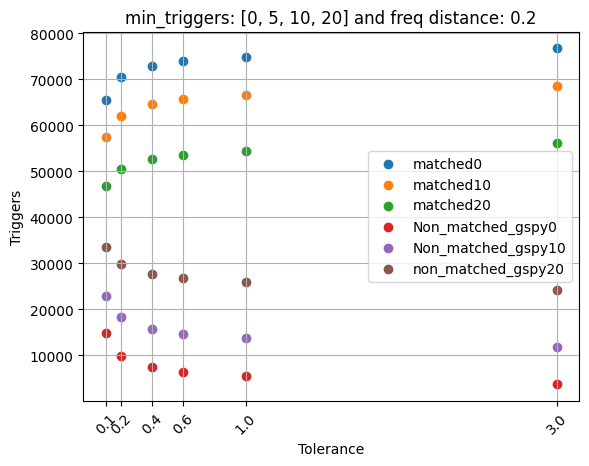

In [17]:
tolerance = [0.1, 0.2, 0.4, 0.6, 1.0, 3.0]

matched0 = [65466, 70546, 72989, 73934, 74917, 76727]
matched5 = [0, 0, 0, 0, 0, 0]
matched10 = [57419, 62110, 64717, 65722, 66601, 68613]
matched20 = [46776, 50615, 52784, 53659, 54500, 56200]

non_matched_gspy0 = [14930, 9850, 7407, 6462, 5479, 3669]
# non_matched_gspy5 = [0, 0, 0, 0, 0, 0]
non_matched_gspy10 = [22977, 18286, 15679, 14674, 13795, 11783]
non_matched_gspy20 = [33620, 29781, 27612, 26737, 25896, 24196]

# non_matched_gdchar = [3690792, 3685712, 3683269, 3682324, 3681341, 3679531]

plt.scatter(tolerance, matched0, label = 'matched0')
# plt.scatter(tolerance, matched5, label = 'matched5')
plt.scatter(tolerance, matched10, label = 'matched10')
plt.scatter(tolerance, matched20, label = 'matched20')

plt.scatter(tolerance, non_matched_gspy0, label = 'Non_matched_gspy0')
# plt.scatter(tolerance, non_matched_gspy5, label = 'non_matched_gspy5')
plt.scatter(tolerance, non_matched_gspy10, label = 'Non_matched_gspy10')
plt.scatter(tolerance, non_matched_gspy20, label = 'non_matched_gspy20')

plt.title(f'min_triggers: [0, 5, 10, 20] and freq distance: 0.2')
plt.ylabel('Triggers')
plt.xlabel('Tolerance')
# plt.yscale('log')

plt.xticks(tolerance, rotation=45)
plt.legend()
plt.grid()
plt.show()

## Generate MATCHEDs Glitchgrams

In [38]:
trigcols = ['time', 'frequency', 'snr']

dtypes = {
    'time': 'float64',
    'frequency': 'float32',
    'snr': 'float32'
}

chunk_size = 10_000_000
chunks, count = [], 0

for chunk in pd.read_csv(base + '/triggers_total.csv', usecols=trigcols, dtype=dtypes, chunksize=chunk_size):
    print(f'Reading chunk: {count}')
    chunks.append(chunk)
    count += 1

trigg = pd.concat(chunks, ignore_index=True)
trigg = trigg.sort_values('time').reset_index(drop=True)

print(f"Total triggers successfully loaded: {len(trigg)}")

unclustered = trigg.copy()
unclustered.tail()

Reading chunk: 0
Reading chunk: 1
Reading chunk: 2
Reading chunk: 3
Reading chunk: 4
Reading chunk: 5
Reading chunk: 6
Reading chunk: 7
Reading chunk: 8
Reading chunk: 9
Reading chunk: 10
Reading chunk: 11
Reading chunk: 12
Reading chunk: 13
Reading chunk: 14
Reading chunk: 15
Reading chunk: 16
Reading chunk: 17
Reading chunk: 18
Reading chunk: 19
Reading chunk: 20
Reading chunk: 21
Reading chunk: 22
Reading chunk: 23
Reading chunk: 24
Reading chunk: 25
Reading chunk: 26
Reading chunk: 27
Reading chunk: 28
Reading chunk: 29
Reading chunk: 30
Reading chunk: 31
Reading chunk: 32
Reading chunk: 33
Reading chunk: 34
Reading chunk: 35
Total triggers successfully loaded: 359385801


,time,frequency,snr
359385796,1.269672e+09,583.020752,38.427120
359385797,1.269672e+09,830.530640,11.973112
359385798,1.269672e+09,474.735565,55.750835
359385799,1.269672e+09,1079.892944,15.370767
359385800,1.269672e+09,879.323059,19.674751


In [298]:
cluster = matched.copy()

clustered_gdchar = cluster[['time', 'frequency', 'snr_x']]
clustered_gspy = cluster[['GPStime', 'peakFreq', 'snr_y']].rename(columns={'GPStime': 'time'})

In [299]:
matrices_match_gdchar, times_gdchar = create_glitchgram(unclustered, clustered_gdchar, deltat)
matrices_match_gspy, times_gspy = create_glitchgram(unclustered, clustered_gspy, deltat)

arr_gdchar = np.array(matrices_match_gdchar)
arr_gspy = np.array(matrices_match_gspy)

Glitchgrams comparison

In [300]:
seed = 17
np.random.seed(seed)

num_total = len(arr_gdchar)
indices_sorteados = np.random.choice(num_total, size=10, replace=False)

indices_sorteados

array([ 742, 1064,  744, 1787,  799, 1580, 1279,  861, 1759, 1835])

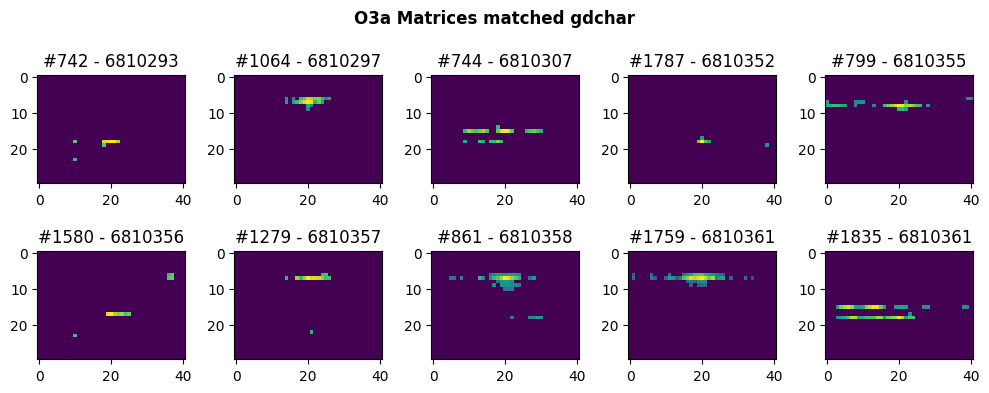

In [301]:
plot_comparison(indices_sorteados, arr_gdchar, times_gdchar, 'matched gdchar', run)

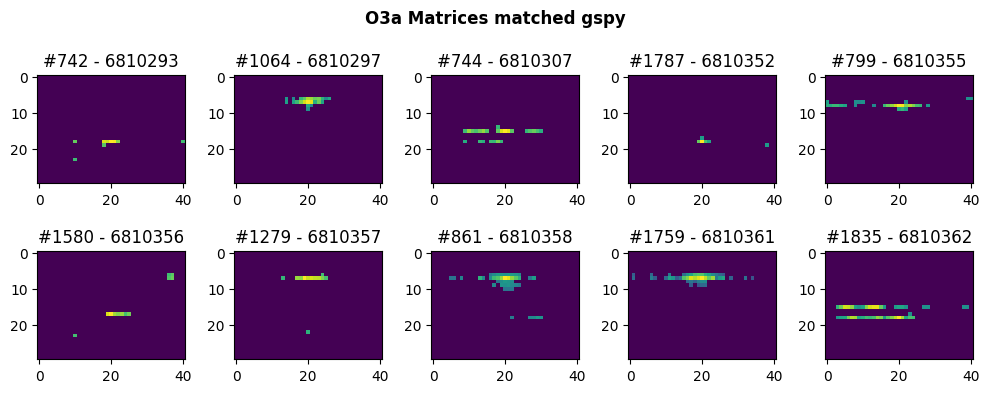

In [302]:
plot_comparison(indices_sorteados, arr_gspy, times_gspy, 'matched gspy', run)

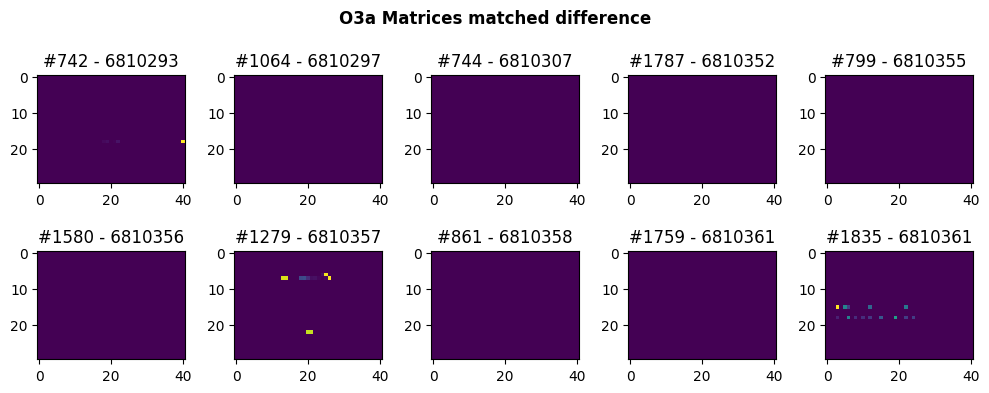

In [303]:
matrice_diff = abs(arr_gdchar - arr_gspy)
plot_comparison(indices_sorteados, matrice_diff, times_gdchar, 'matched difference', run)

By examining the glitchgrams from our clustering process and Gravity Spy, we concluded that our match is correct. 

The difference glitchgrams confirm that the data are not identical but merely exhibit a slight temporal offset relative to each other.

## Generate NON_MATCHED glitchgrams

In [304]:
cluster1 = non_matched_gdchar.copy()
cluster2 = non_matched_gspy.copy()

clustered_gdchar = cluster1[['time', 'frequency', 'snr']]
clustered_gspy = cluster2[['GPStime', 'peakFreq', 'snr']].rename(columns={'GPStime': 'time'})

In [305]:
clustered_gspy

,time,peakFreq,snr
0,1.247335e+09,377.468,7.644
1,1.247336e+09,377.468,10.180
2,1.247336e+09,381.052,9.122
3,1.247337e+09,162.791,11.514
4,1.247338e+09,377.468,9.312
...,...,...,...
820,1.247697e+09,381.052,9.098
821,1.247697e+09,162.791,9.709
822,1.247697e+09,162.791,9.382
823,1.247697e+09,162.791,7.526


In [306]:
clustered_gdchar

,time,frequency,snr
0,1.246810e+09,27.352067,7.478599
1,1.246810e+09,91.747436,9.375890
2,1.246810e+09,220.779202,9.482150
3,1.246810e+09,287.380511,8.530852
4,1.246810e+09,722.310266,6.468280
...,...,...,...
2494,1.247700e+09,21.528402,7.908107
2495,1.247700e+09,19.494597,7.010584
2496,1.247700e+09,20.913994,8.983240
2497,1.247701e+09,32.842241,595.648812


In [307]:
'''t_inicio_gps = int(Time('2019-07-10T10:00:00', format='isot', scale='utc').gps) # 1246626018
t_fim_gps    = int(Time('2019-07-11T23:00:00', format='isot', scale='utc').gps) # 1246633218'''

start_day_O3a = datetime(2019, 7, 18, 0, 0, 0)
end_day_O3a   = datetime(2019, 7, 18, 23, 0, 0)

t_inicio_gps = Time(start_day_O3a, scale="utc").gps
t_fim_gps   = Time(end_day_O3a, scale="utc").gps

clustered_gdchar = clustered_gdchar.sort_values(by="time").reset_index(drop=True)
clustered_gspy = clustered_gspy.sort_values(by="time").reset_index(drop=True)

mask_gdchar = (clustered_gdchar['time'] >= t_inicio_gps) & (clustered_gdchar['time'] <= t_fim_gps)
mask_gspy = (clustered_gspy['time'] >= t_inicio_gps) & (clustered_gspy['time'] <= t_fim_gps)

matrices_nomatch_gdchar, times_non_gdchar = create_glitchgram(unclustered, clustered_gdchar, deltat)
matrices_nomatch_gspy, times_non_gspy = create_glitchgram(unclustered, clustered_gspy, deltat)

In [308]:
arr_gdchar1 = np.array(matrices_nomatch_gdchar)[mask_gdchar]
times_gdchar1 = np.array(times_non_gdchar)[mask_gdchar]

idx_gdchar = np.argsort(times_gdchar1)
arr_gdchar1 = arr_gdchar1[idx_gdchar]
times_gdchar1 = times_gdchar1[idx_gdchar]

In [309]:
arr_gspy2 = np.array(matrices_nomatch_gspy)[mask_gspy]
times_gspy2 = np.array(times_non_gspy)[mask_gspy]

idx_gspy = np.argsort(times_gspy2)
arr_gspy2 = arr_gspy2[idx_gspy]
times_gspy2 = times_gspy2[idx_gspy]



In [310]:
plot_grid(arr_gdchar1, times_gdchar1, "Non-Matched GDCHAR")

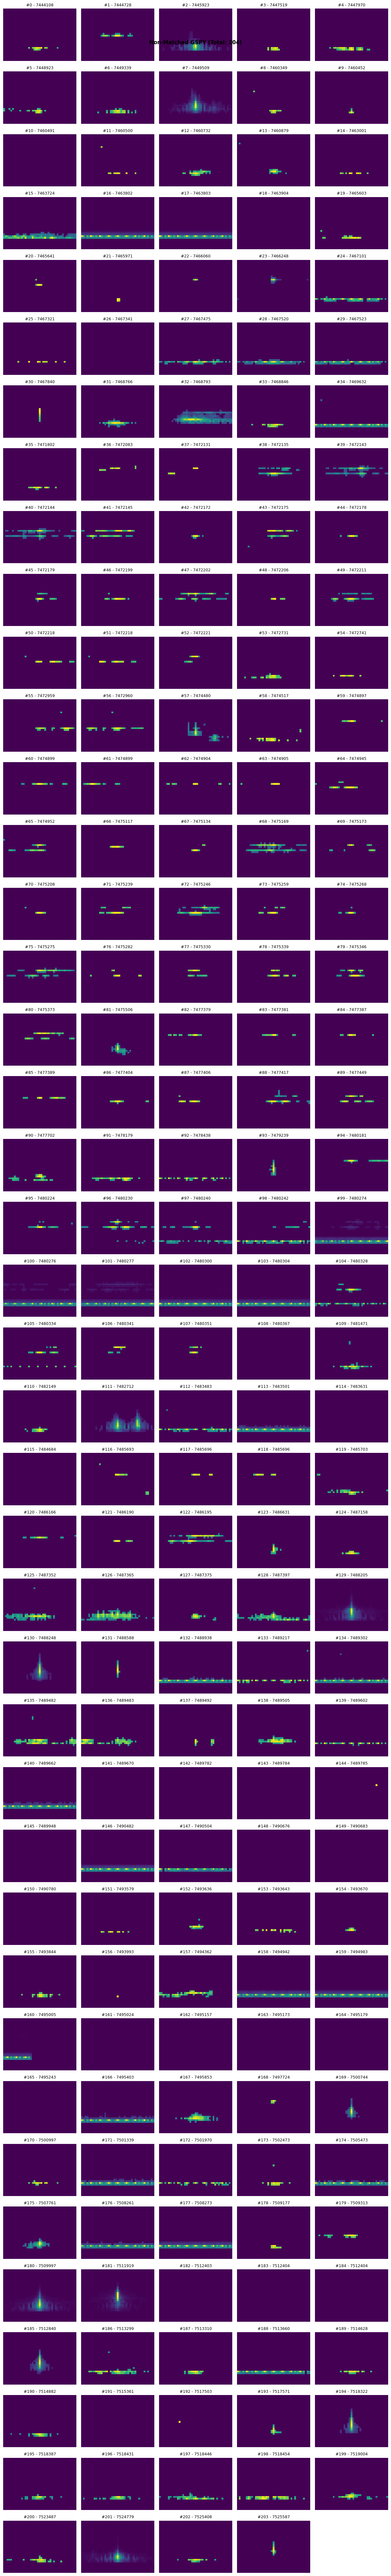

In [311]:
plot_grid(arr_gspy2, times_gspy2, "Non-Matched GSPY")

### Encontrar para cada tempo em gdchar se existe algum próximo em gspy

In [316]:
# Tolerância em segundos (ex: 10 milissegundos)
dt = 1

# Encontra para cada tempo em gdchar se existe algum próximo em gspy
# (Como os arrays já estão ordenados por tempo no seu código, searchsorted é extremamente rápido)
idx_gspy_nearest = np.searchsorted(times_gspy2, times_gdchar1)
idx_gspy_nearest = np.clip(idx_gspy_nearest, 0, len(times_gspy2) - 1)

# Calcula a diferença absoluta de tempo
time_diff = np.abs(times_gdchar1 - times_gspy2[idx_gspy_nearest])

# Máscara de interseções dentro da tolerância dt
mask_intersect = time_diff <= dt

# Tempos e matrizes que deram match dentro da janela dt:
common_times_gdchar = times_gdchar1[mask_intersect]
common_arr_gdchar   = arr_gdchar1[mask_intersect]

common_times_gspy   = times_gspy2[idx_gspy_nearest[mask_intersect]]
common_arr_gspy     = arr_gspy2[idx_gspy_nearest[mask_intersect]]

print(f"Total de glitches próximos em dt < {dt}s: {len(common_times_gdchar)}")

Total de glitches próximos em dt < 1s: 1


In [317]:
common_times_gdchar

array([1.24750547e+09])

In [318]:
common_times_gspy

array([1.24750547e+09])

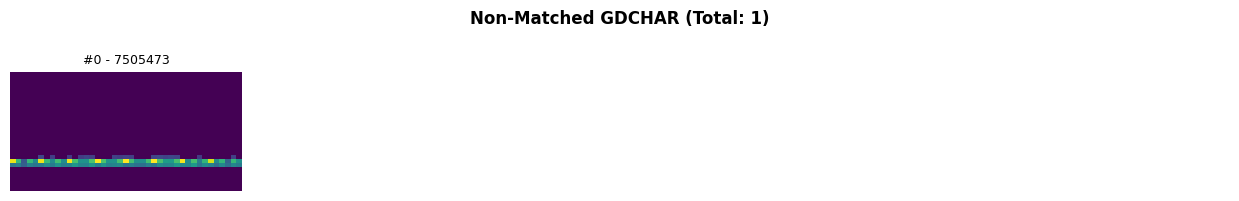

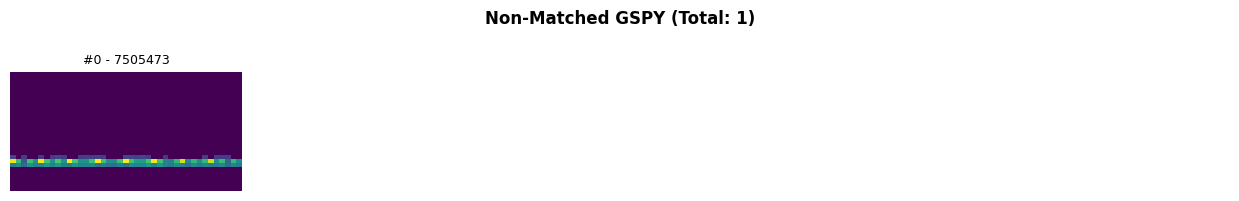

In [320]:
plot_grid(common_arr_gdchar, common_times_gdchar, "Non-Matched GDCHAR")
plot_grid(common_arr_gspy, common_times_gspy, "Non-Matched GSPY")

### Encontrar o glitch mais próximo de um determinado tempo GPS

In [325]:
X = 1247468793.0

In [326]:
idx_nearest_gdchar = np.argmin(np.abs(times_gdchar1 - X))
closest_time_gdchar = times_gdchar1[idx_nearest_gdchar]
diff_gdchar = abs(closest_time_gdchar - X)

print(f'closest_time_gdchar: {closest_time_gdchar} \n')
print(f'diff_gdchar: {diff_gdchar} \n')

closest_time_gdchar: 1247468799.4375 

diff_gdchar: 6.4375 



In [327]:
idx_nearest_gspy = np.argmin(np.abs(times_gspy2 - X))
closest_time_gspy = times_gdchar1[idx_nearest_gspy]
diff_gspy = abs(closest_time_gspy - X)

print(f'closest_time_gspy: {closest_time_gspy} \n')
print(f'diff_gspy: {diff_gspy} \n')

closest_time_gspy: 1247461107.167968 

diff_gspy: 7685.832031965256 



In [45]:
# 1. Verifica quantos eventos existem no intervalo no DataFrame original
qtd_df = mask_gspy.sum()
print(f"Glitches de GSPY no intervalo de tempo (no DataFrame): {qtd_df}")

# 2. Verifica se a função retornou a mesma quantidade de matrizes/tempos
print(f"Total de matrizes geradas pelo create_glitchgram: {len(matrices_nomatch_gspy)}")
print(f"Total de tempos gerados pelo create_glitchgram: {len(times_non_gspy)}")

# 3. Solução robusta: Criar a máscara diretamente no array retornado pela função!
times_gspy_arr = np.array(times_non_gspy)
matrices_gspy_arr = np.array(matrices_nomatch_gspy)

# Máscara feita diretamente nos tempos retornados pela função (sem perigo de tamanho desalinhado)
mask_real_gspy = (times_gspy_arr >= t_inicio_gps) & (times_gspy_arr <= t_fim_gps)

arr_gspy2 = matrices_gspy_arr[mask_real_gspy]
times_gspy2 = times_gspy_arr[mask_real_gspy]

# Ordenar
idx_gspy = np.argsort(times_gspy2)
arr_gspy2 = arr_gspy2[idx_gspy]
times_gspy2 = times_gspy2[idx_gspy]

print(f"Glitches finais filtrados para plotar: {len(arr_gspy2)}")

Glitches de GSPY no intervalo de tempo (no DataFrame): 0
Total de matrizes geradas pelo create_glitchgram: 18374
Total de tempos gerados pelo create_glitchgram: 18374
Glitches finais filtrados para plotar: 0


In [46]:
print("Tempo MÍNIMO do GSPY:", clustered_gspy["time"].min())
print("Tempo MÁXIMO do GSPY:", clustered_gspy["time"].max())

print("\nSeu t_inicio_gps:", t_inicio_gps)
print("Seu t_fim_gps   :", t_fim_gps)

Tempo MÍNIMO do GSPY: 1250800400.002
Tempo MÁXIMO do GSPY: 1253976851.266

Seu t_inicio_gps: 1246701618
Seu t_fim_gps   : 1246824018
